In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

In [4]:
df = pd.read_csv("../files/early_diabetes_data_cleaned.csv")

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

In [4]:
dtc = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'max_leaf_nodes': [5, 10, 20],
}

gcv = GridSearchCV(dtc, param_grid=param_grid, n_jobs=-1)

gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_leaf_nodes': [5, 10, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

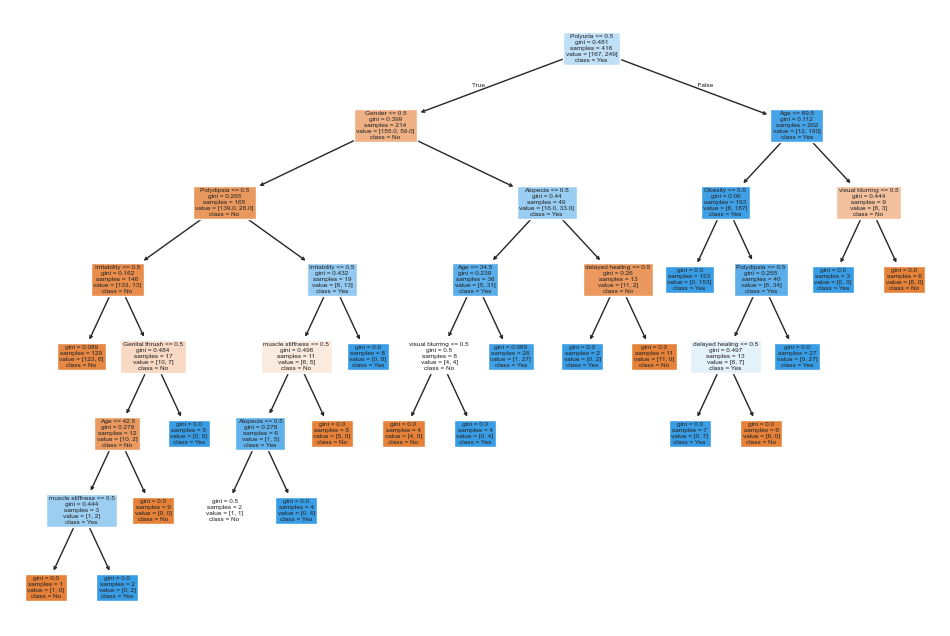

In [5]:
opt_dtc = gcv.best_estimator_
opt_dtc.fit(X_train, y_train)

opt_dtc_proba = opt_dtc.predict_proba(X_test)

plt.figure(figsize=(12,8))
plot_tree(opt_dtc, feature_names=X_test.columns, class_names=["No", "Yes"], filled=True)
plt.savefig("tree.pdf", bbox_inches="tight")
plt.show()

In [6]:
# Predictions
y_pred_proba = opt_dtc.predict_proba(X_test)
y_pred = opt_dtc.predict(X_test)

# Metric : Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Metric : AUC score
roc_auc = roc_auc_score(y_test, y_pred)

# Rates
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[33  0]
 [ 6 65]]


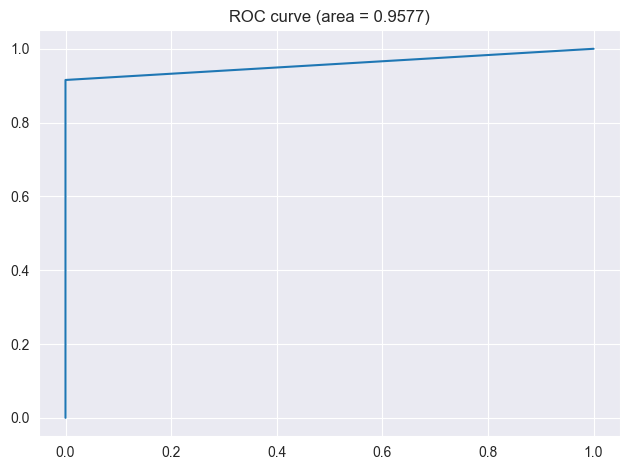

In [7]:
fig = plt.subplot()

fig.plot(fpr,tpr)
plt.title(f"ROC curve (area = {round(roc_auc, 4)})")
plt.tight_layout()
plt.show()

In [27]:
classifier = DecisionTreeClassifier(random_state=42, min_samples_leaf=10)
path = classifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.00032259, 0.00033387, 0.00198388, 0.00204054,
       0.00417334, 0.00963408, 0.01231726, 0.02296946, 0.02863126,
       0.04834185, 0.22085751])

In [28]:
# param_grid = {
#     'ccp_alpha': ccp_alphas
# }

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'max_leaf_nodes': [5, 10, 20],
    'ccp_alpha': ccp_alphas
}

gcv = GridSearchCV(classifier, param_grid=param_grid, n_jobs=-1)
gcv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': array([0. ..., 0.22085751]), 'max_depth': [None, 5, ...], 'max_leaf_nodes': [5, 10, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [29]:
opt_dtc2 = gcv.best_estimator_
opt_dtc2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [30]:
# Predictions
y_pred_proba = opt_dtc2.predict_proba(X_test)
y_pred = opt_dtc2.predict(X_test)

# Metric : Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Metric : AUC score
roc_auc = roc_auc_score(y_test, y_pred)

# Rates
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28  5]
 [ 2 69]]


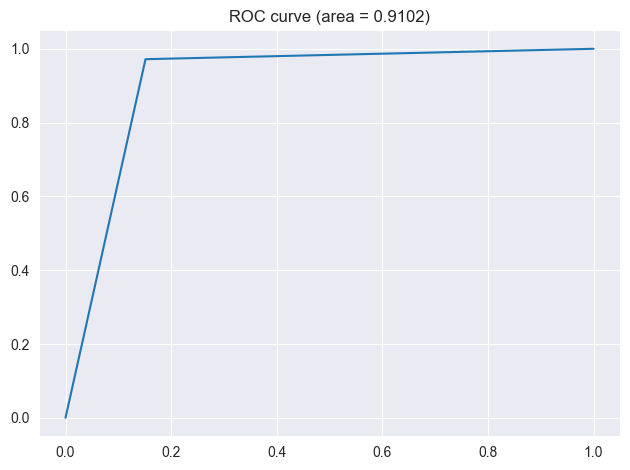

In [31]:
fig = plt.subplot()

fig.plot(fpr,tpr)
plt.title(f"ROC curve (area = {round(roc_auc, 4)})")
plt.tight_layout()
plt.show()

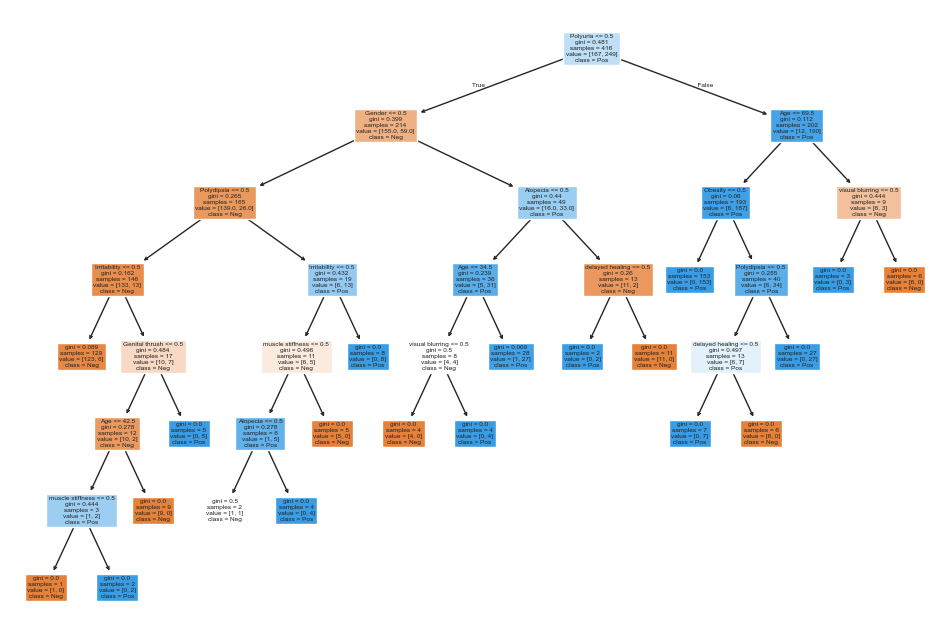

In [26]:
plt.figure(figsize=(12,8))
plot_tree(opt_dtc2, feature_names=X_test.columns, class_names=["Neg", "Pos"], filled=True)
plt.savefig("tree.pdf", bbox_inches="tight")
plt.show()

In [233]:
min_val = np.min(df['Age'].astype(int))
max_val = np.max(df['Age'].astype(int))

n_bins = 5
bins = np.linspace(min_val, max_val, n_bins + 1)
bins = np.round(bins).astype(int)

bins = np.unique(bins)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df["Age group"] = pd.cut(df['Age'], bins=bins, labels=bin_labels, include_lowest=True)

In [254]:
labels = ['Age group', 'class']
sliced = df.loc[:,labels]

new_labels = ['Age group', 'Positive', 'Negative']

diabetes_per_df = sliced.groupby('Age group').mean().reset_index()
diabetes_per_df['Negative'] = 1 - diabetes_per_df['class']
diabetes_per_df.columns = new_labels

diabetes_per_df

,Age group,Positive,Negative
0,16-31,0.375000,0.625000
1,31-46,0.581152,0.418848
2,46-60,0.671642,0.328358
3,60-75,0.680000,0.320000
4,75-90,1.000000,0.000000


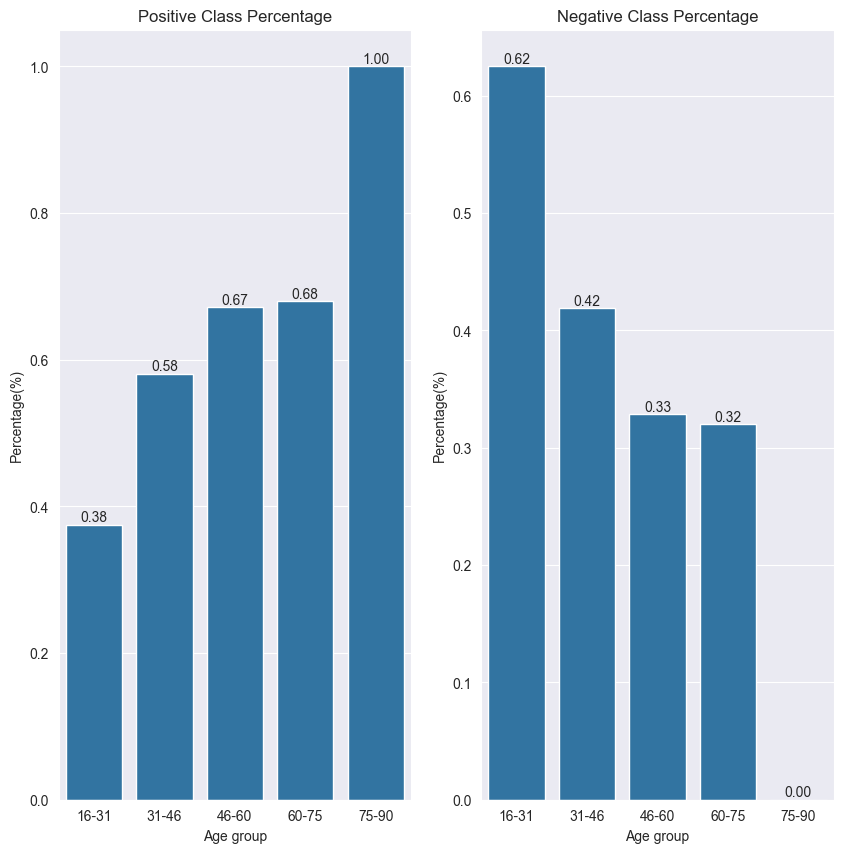

In [259]:
fig, axs = plt.subplots(1,2,figsize=(10,10))

for idx, ax in enumerate(axs.flat):
    occur = ['Positive', 'Negative']

    sns.barplot(data=diabetes_per_df, x = 'Age group', y = occur[idx], ax=ax)
    ax.set_ylabel('Percentage(%)')
    ax.set_title(f'{occur[idx]} Class Percentage')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

In [235]:
positive_class = df[df['class'] == 1]
binned_mean = np.transpose(positive_class.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

combined = binned_mean.melt(
    id_vars="Factor",
    value_vars=bin_group,
    var_name="Group",
    value_name="Value"
)

In [226]:
binned_mean = np.transpose(df.groupby('Age group').mean().drop('Age', axis=1))
bin_group = binned_mean.columns
cols = pd.concat([pd.Series(['Factor']), pd.Series(binned_mean.columns)])
binned_mean.reset_index(inplace=True)
binned_mean.columns = cols

combined = binned_mean.melt(
    id_vars="Factor",
    value_vars=bin_group,
    var_name="Group",
    value_name="Value"
)

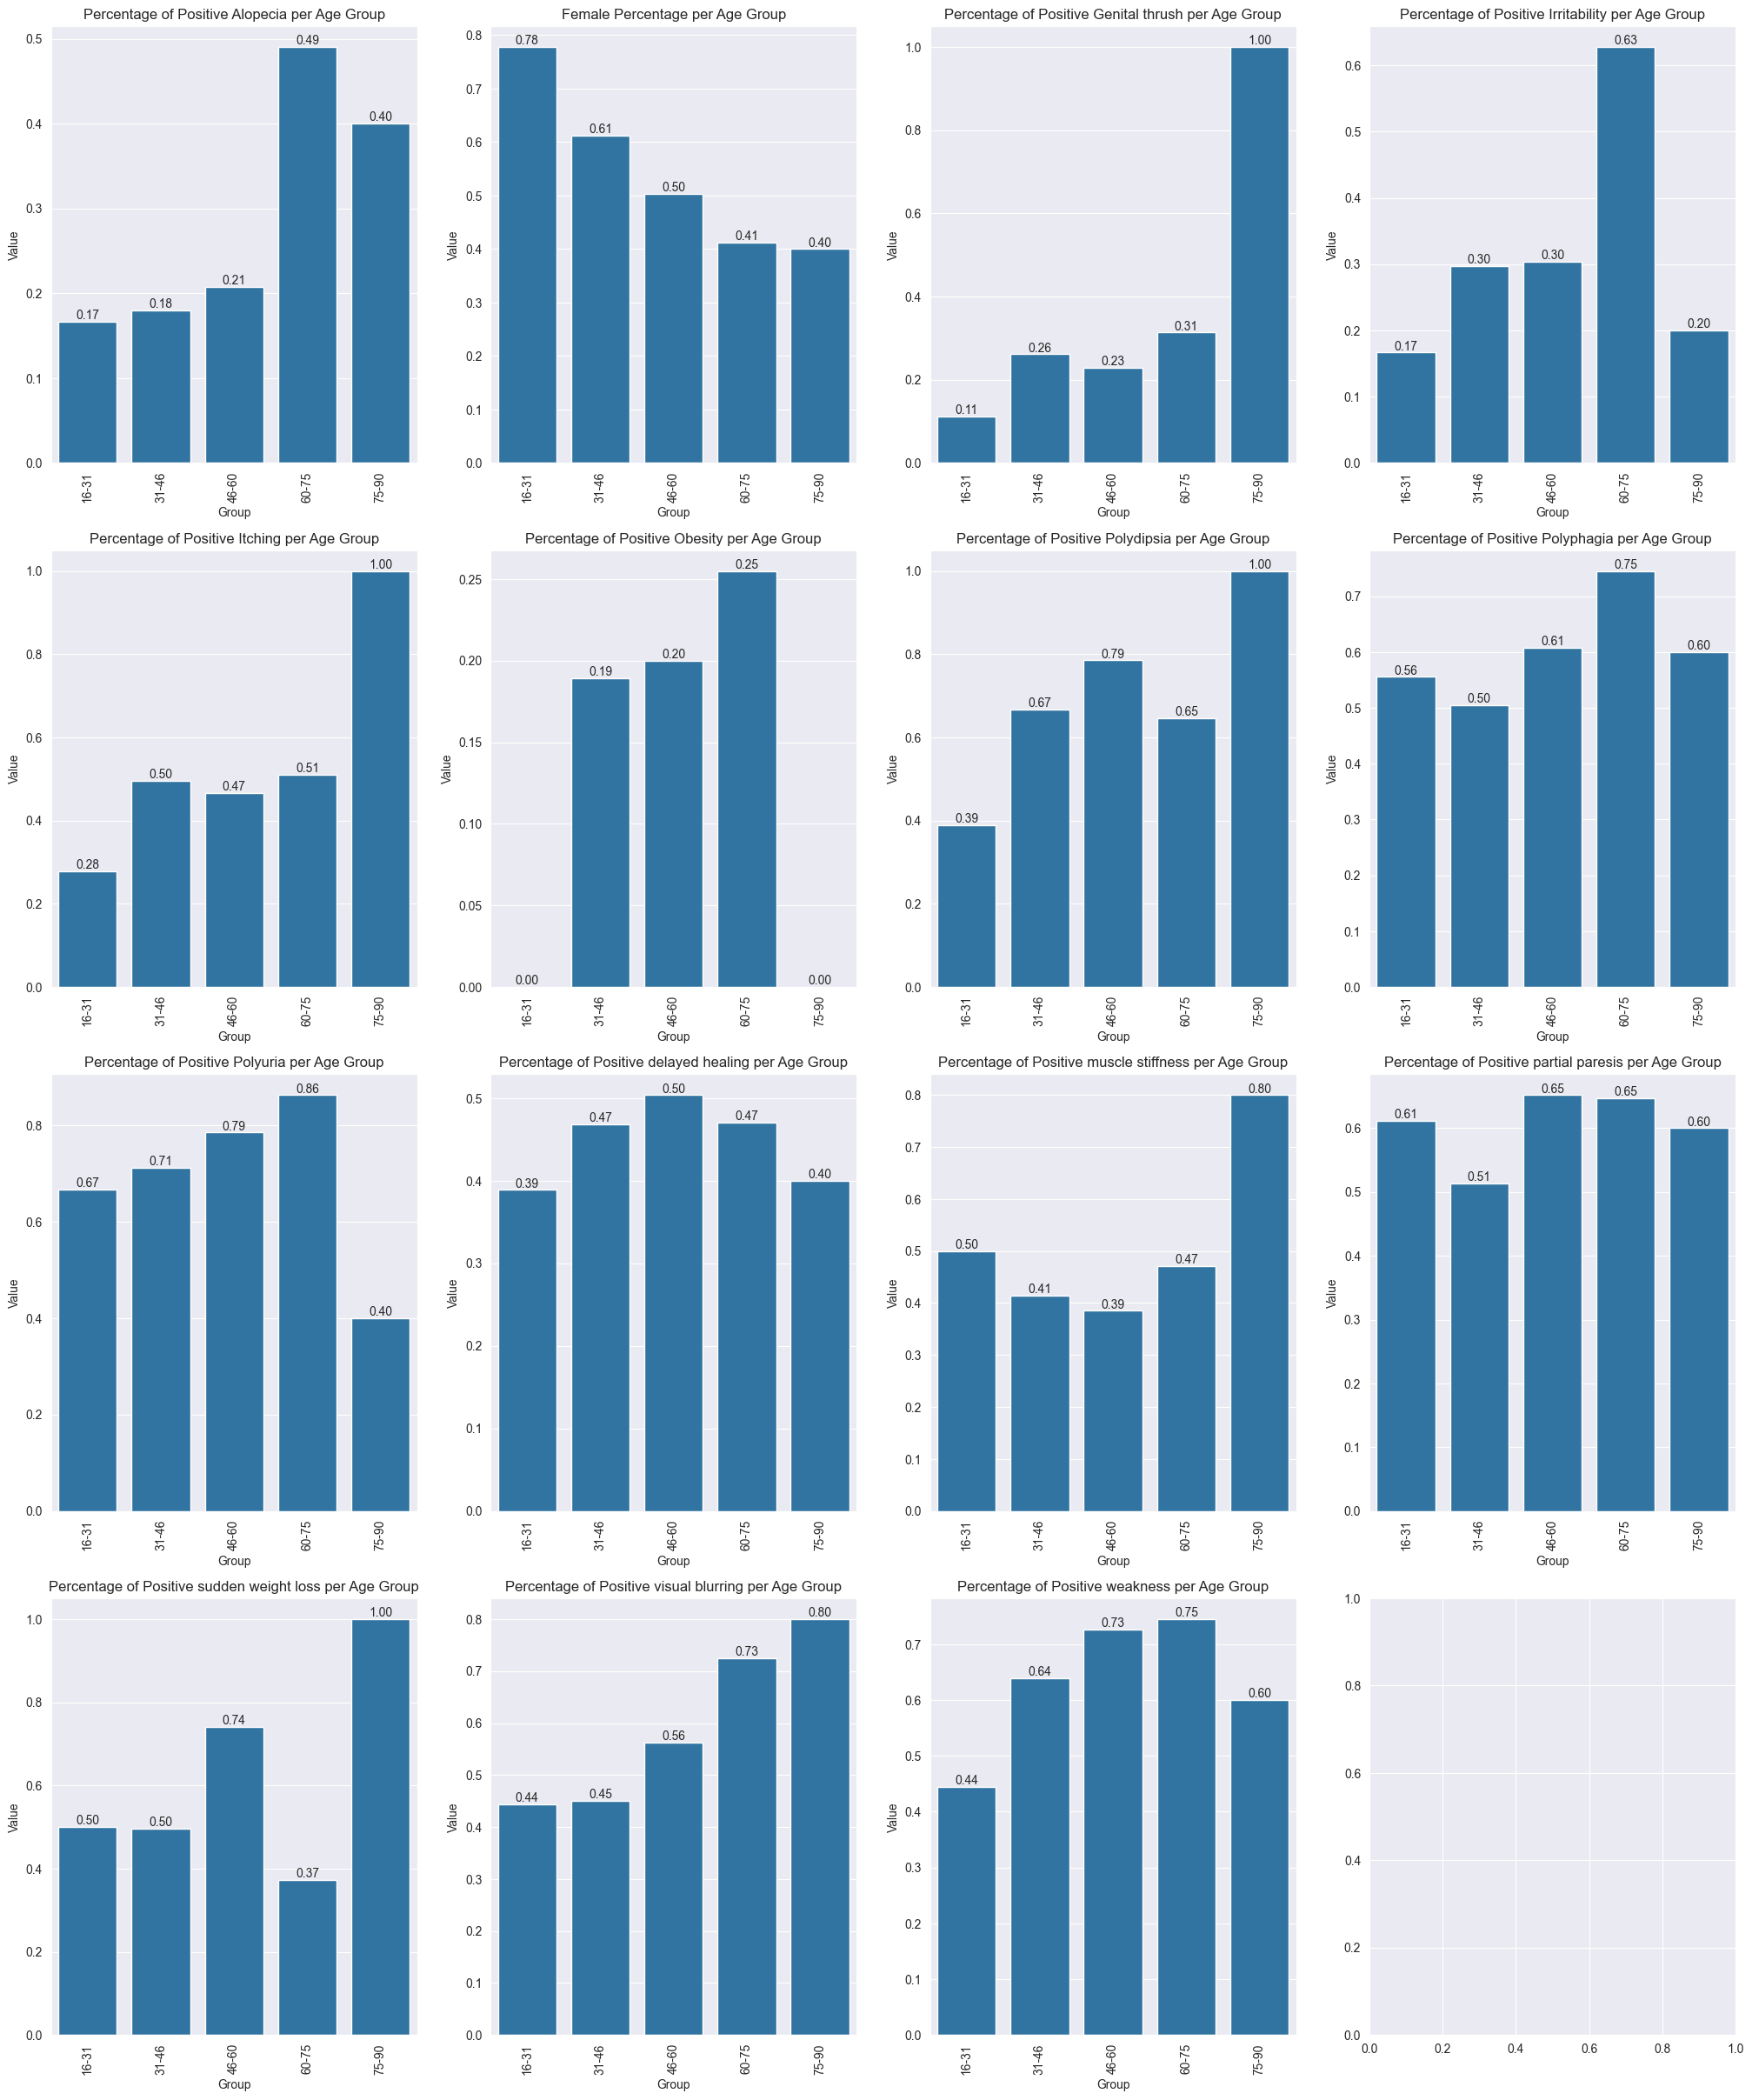

In [232]:
fig, axs = plt.subplots(4, 4, figsize=(25,30))
factors = np.unique(combined['Factor'])

mask = factors != 'class'
factors = factors[mask]

for idx, ax in enumerate(axs.flat):
    if idx != factors.size:
        factor = factors[idx]
        factor_df = combined[combined['Factor'] == factor]

        sns.barplot(data=factor_df, y = 'Value',x = 'Group', ax=ax)

        if factor == 'Gender':
            ax.set_title(f"Female Percentage per Age Group")
        elif factor == 'class':
            ax.set_title(f"Positive Diabetes Percentage per Age Group")
        else:
            ax.set_title(f"Percentage of Positive {factor} per Age Group")
        ax.tick_params(axis='x', rotation=90)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f")
